# Q-learning vs SARSA Results Comparison

This notebook loads the finished training outputs from `outputs/logs`, plots both algorithms, and summarizes which one performed better on this run.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "outputs" / "logs").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root with outputs/logs and README.md")

PROJECT_ROOT = find_project_root(Path.cwd())
LOGS_DIR = PROJECT_ROOT / "outputs" / "logs"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

q_seed_path = LOGS_DIR / "q_learning_discrete_separate_seed_results.csv"
s_seed_path = LOGS_DIR / "sarsa_discrete_seed_results.csv"
q_agg_path = LOGS_DIR / "q_learning_discrete_separate_aggregate.json"
s_agg_path = LOGS_DIR / "sarsa_discrete_aggregate.json"

q_seed_df = pd.read_csv(q_seed_path)
s_seed_df = pd.read_csv(s_seed_path)

with open(q_agg_path, "r", encoding="utf-8") as f:
    q_agg = json.load(f)
with open(s_agg_path, "r", encoding="utf-8") as f:
    s_agg = json.load(f)

combined_seed_df = pd.concat([q_seed_df, s_seed_df], ignore_index=True)
combined_seed_df

,experiment_name,seed,algorithm,episodes,mean_reward,std_reward,success_rate,mean_episode_length,last_eval_mean_reward,model_path,policy_path
0,q_learning_discrete_separate,7,q_learning,2000,-196.9705,9.645394,0.1235,196.9705,-200.00,outputs\models\q_learning_discrete_separate_se...,outputs\models\q_learning_discrete_separate_se...
1,q_learning_discrete_separate,21,q_learning,2000,-197.9610,7.826460,0.1060,197.9610,-181.45,outputs\models\q_learning_discrete_separate_se...,outputs\models\q_learning_discrete_separate_se...
2,q_learning_discrete_separate,42,q_learning,2000,-198.3885,6.241440,0.1060,198.3885,-194.45,outputs\models\q_learning_discrete_separate_se...,outputs\models\q_learning_discrete_separate_se...
3,sarsa_discrete,7,sarsa,2000,-194.9715,12.289007,0.2065,194.9715,-199.35,outputs\models\sarsa_discrete_seed7_final,outputs\models\sarsa_discrete_seed7_policy.npy
4,sarsa_discrete,21,sarsa,2000,-195.5150,11.776535,0.1810,195.5150,-180.20,outputs\models\sarsa_discrete_seed21_final,outputs\models\sarsa_discrete_seed21_policy.npy
5,sarsa_discrete,42,sarsa,2000,-195.5620,11.715765,0.1780,195.5620,-181.30,outputs\models\sarsa_discrete_seed42_final,outputs\models\sarsa_discrete_seed42_policy.npy


C:\Users\hugok\AppData\Local\Temp\ipykernel_15156\1490849327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hugok\AppData\Local\Temp\ipykernel_15156\1490849327.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


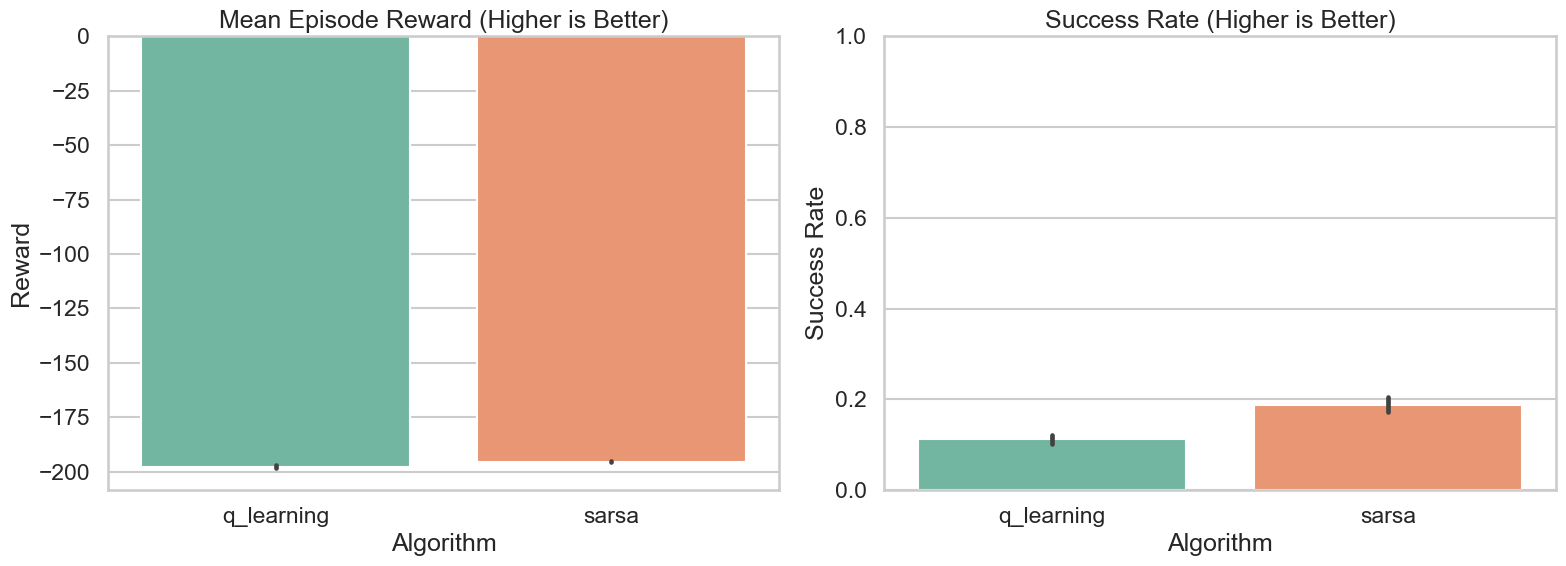

Saved: C:\Users\hugok\OneDrive\Dokumenty\GitHub\mountain-pendulum\outputs\figures\q_learning_vs_sarsa_seed_summary.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=combined_seed_df,
    x="algorithm",
    y="mean_reward",
    estimator=np.mean,
    errorbar="sd",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Mean Episode Reward (Higher is Better)")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("Reward")

sns.barplot(
    data=combined_seed_df,
    x="algorithm",
    y="success_rate",
    estimator=np.mean,
    errorbar="sd",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Success Rate (Higher is Better)")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("Success Rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
out_path = FIG_DIR / "q_learning_vs_sarsa_seed_summary.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

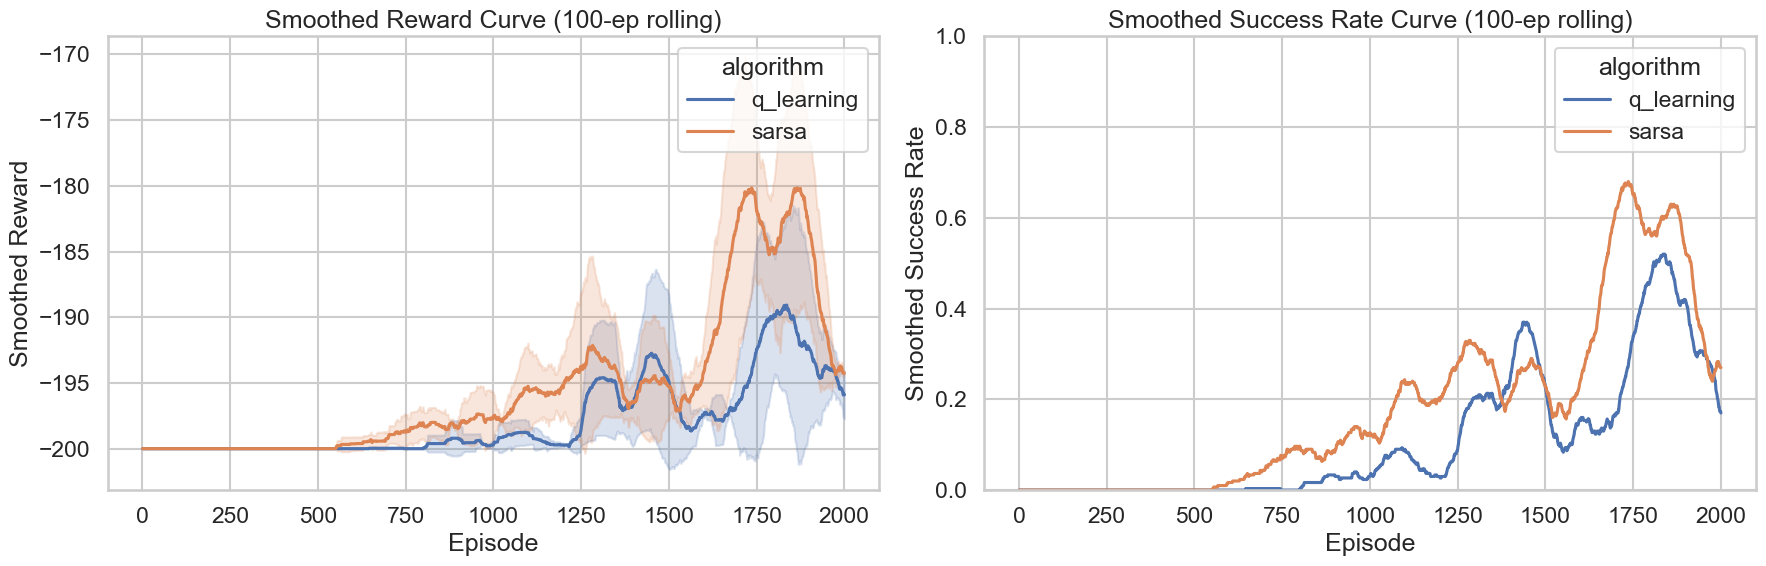

Saved: C:\Users\hugok\OneDrive\Dokumenty\GitHub\mountain-pendulum\outputs\figures\q_learning_vs_sarsa_learning_curves.png


In [3]:
def load_episode_curves(prefix: str, seeds: list[int]) -> pd.DataFrame:
    frames = []
    for seed in seeds:
        path = LOGS_DIR / f"{prefix}_seed{seed}_episodes.csv"
        df = pd.read_csv(path)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

q_seeds = sorted(q_seed_df["seed"].unique().tolist())
s_seeds = sorted(s_seed_df["seed"].unique().tolist())

q_ep = load_episode_curves("q_learning_discrete_separate", q_seeds)
q_ep["algorithm"] = "q_learning"
s_ep = load_episode_curves("sarsa_discrete", s_seeds)
s_ep["algorithm"] = "sarsa"
ep = pd.concat([q_ep, s_ep], ignore_index=True)

ep = ep.sort_values(["algorithm", "seed", "episode"]).reset_index(drop=True)
ep["reward_smooth"] = ep.groupby(["algorithm", "seed"]) ["reward"].transform(
    lambda x: x.rolling(window=100, min_periods=1).mean()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=ep,
    x="episode",
    y="reward_smooth",
    hue="algorithm",
    estimator="mean",
    errorbar="sd",
    ax=axes[0],
)
axes[0].set_title("Smoothed Reward Curve (100-ep rolling)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Smoothed Reward")

success_ep = ep.groupby(["algorithm", "episode"], as_index=False)["success"].mean()
success_ep["success_smooth"] = success_ep.groupby("algorithm")["success"].transform(
    lambda x: x.rolling(window=100, min_periods=1).mean()
)

sns.lineplot(
    data=success_ep,
    x="episode",
    y="success_smooth",
    hue="algorithm",
    ax=axes[1],
)
axes[1].set_title("Smoothed Success Rate Curve (100-ep rolling)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Smoothed Success Rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
out_path = FIG_DIR / "q_learning_vs_sarsa_learning_curves.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [4]:
comparison = pd.DataFrame(
    [
        {
            "algorithm": "q_learning",
            "mean_reward": q_agg["mean_reward"],
            "std_reward_across_seeds": q_agg["std_reward_across_seeds"],
            "mean_success_rate": q_agg["mean_success_rate"],
        },
        {
            "algorithm": "sarsa",
            "mean_reward": s_agg["mean_reward"],
            "std_reward_across_seeds": s_agg["std_reward_across_seeds"],
            "mean_success_rate": s_agg["mean_success_rate"],
        },
    ]
)

display(comparison.sort_values("mean_reward", ascending=False))

best_reward_algo = comparison.loc[comparison["mean_reward"].idxmax(), "algorithm"]
best_success_algo = comparison.loc[comparison["mean_success_rate"].idxmax(), "algorithm"]

print("Comparison summary:")
print(f"- Best by reward: {best_reward_algo}")
print(f"- Best by success rate: {best_success_algo}")
print(f"- Reward gap (sarsa - q_learning): {s_agg['mean_reward'] - q_agg['mean_reward']:.4f}")
print(f"- Success-rate gap (sarsa - q_learning): {s_agg['mean_success_rate'] - q_agg['mean_success_rate']:.4f}")

,algorithm,mean_reward,std_reward_across_seeds,mean_success_rate
1,sarsa,-195.349500,0.267974,0.188500
0,q_learning,-197.773333,0.593911,0.111833


Comparison summary:
- Best by reward: sarsa
- Best by success rate: sarsa
- Reward gap (sarsa - q_learning): 2.4238
- Success-rate gap (sarsa - q_learning): 0.0767
